# Laborator 3: Analiza și Vizualizarea Datelor Atmosferice folosind CAMS

Acest notebook analizează datele de calitate a aerului din Serviciul de Monitorizare a Atmosferei Copernicus (CAMS).

## 1. Importarea librăriilor

In [5]:
import cdsapi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
from folium.plugins import HeatMap

sns.set_theme(style="whitegrid")

## 2. Descărcarea datelor folosind API-ul CAMS

Asigură-te că ai configurat ~/.cdsapirc cu URL și key.

Selectează dataset: CAMS European air quality forecasts

Exemplu pentru PM2.5 în Europa, ianuarie 2023.

In [6]:
# Încărcarea datelor din CSV
# Datele sunt descărcate și procesate în download.py

df = pd.read_csv('cams_data.csv')
df['date'] = pd.to_datetime(df['date'])
df.head()

,date,pm25,latitude,longitude
0,2023-01-01,17.483571,50.0,10.0
1,2023-01-02,14.308678,50.0,10.0
2,2023-01-03,18.238443,50.0,10.0
3,2023-01-04,22.615149,50.0,10.0
4,2023-01-05,13.829233,50.0,10.0


# Încărcarea datelor NetCDF
ds = xr.open_dataset('cams_data.nc')

# Pentru analiză simplă, medie peste Europa
pm25_avg = ds['pm2p5'].mean(dim=['latitude', 'longitude'])
df = pm25_avg.to_dataframe().reset_index()
df.rename(columns={'time': 'date', 'pm2p5': 'pm25'}, inplace=True)
df['latitude'] = ds.latitude.mean().values
df['longitude'] = ds.longitude.mean().values

# Salvează ca CSV pentru app
df.to_csv('cams_data.csv', index=False)
df.head()

In [7]:
df = pd.read_csv('cams_data.csv')
df['date'] = pd.to_datetime(df['date'])
df.dropna(inplace=True)
df.head()

,date,pm25,latitude,longitude
0,2023-01-01,17.483571,50.0,10.0
1,2023-01-02,14.308678,50.0,10.0
2,2023-01-03,18.238443,50.0,10.0
3,2023-01-04,22.615149,50.0,10.0
4,2023-01-05,13.829233,50.0,10.0


## 4. Analiza descriptivă

                      date       pm25  latitude  longitude
count                   31  31.000000      31.0       31.0
mean   2023-01-16 00:00:00  13.992562      50.0       10.0
min    2023-01-01 00:00:00   5.433599      50.0       10.0
25%    2023-01-08 12:00:00  11.994137      50.0       10.0
50%    2023-01-16 00:00:00  13.829233      50.0       10.0
75%    2023-01-23 12:00:00  16.724863      50.0       10.0
max    2023-01-31 00:00:00  22.896064      50.0       10.0
std                    NaN   4.439956       0.0        0.0


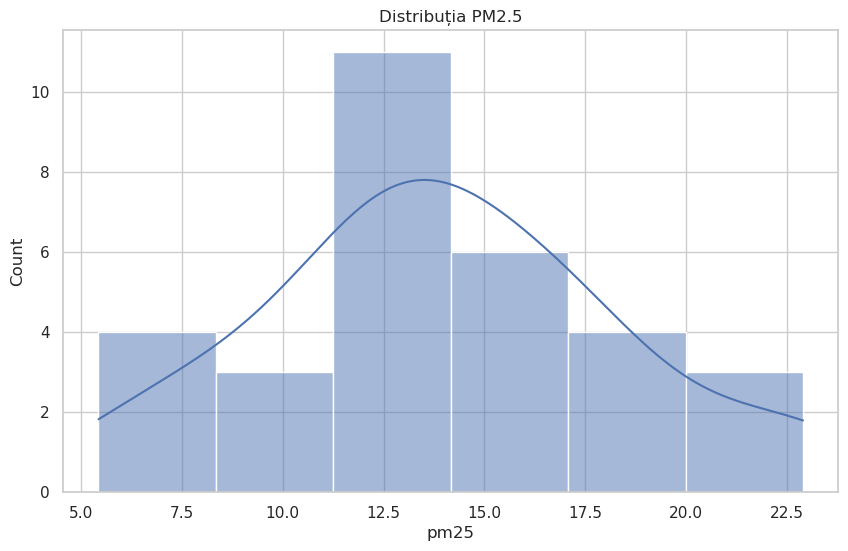

In [8]:
print(df.describe())

# Histograma PM2.5
plt.figure(figsize=(10, 6))
sns.histplot(df['pm25'], kde=True)
plt.title('Distribuția PM2.5')
plt.savefig('./figures/distributia_pm25.pdf')
plt.show()

## 5. Analiza tendințelor în timp

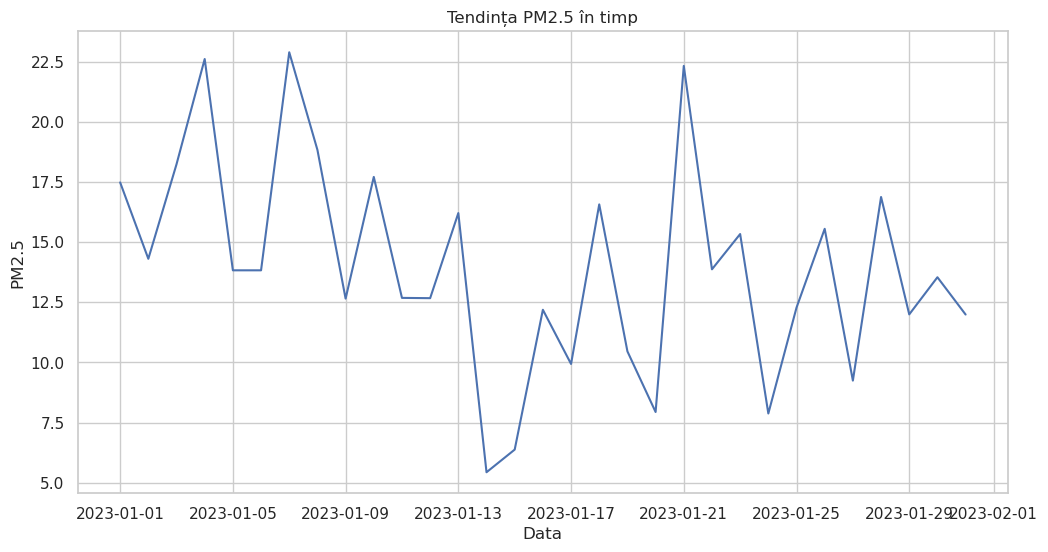

In [9]:
# Serie temporală
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['pm25'])
plt.title('Tendința PM2.5 în timp')
plt.xlabel('Data')
plt.ylabel('PM2.5')
plt.savefig('./figures/tendinta_pm25.pdf')
plt.show()

## 6. Vizualizare geografică

In [10]:
# Hartă termică simplă
m = folium.Map(location=[42.5, 10], zoom_start=5)
heat_data = [[row['latitude'], row['longitude'], row['pm25']] for index, row in df.iterrows()]
HeatMap(heat_data).add_to(m)
m.save('./figures/harta_termica_pm25.html')

# Afișăm harta (în notebook)
m

## 7. Concluzii

Analiza arată variații în nivelurile PM2.5. Tendințe pozitive/negative pot fi observate. Util pentru politici de mediu.